In [4]:
import numpy as np
import plotly.graph_objects as go
from scipy.spatial.distance import cdist

# -----------------------------------------------------------------------------
# 1. SETUP CONTINUOUS 3D GRID PARAMETERS
# -----------------------------------------------------------------------------
nx, ny, nz = 25, 25, 15  # Grid dimensions
x = np.linspace(0, 100, nx)  # Dimensions in meters
y = np.linspace(0, 100, ny)
z = np.linspace(0, 50, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Reshape coordinates for spatial distance matrix calculation
coords = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

# -----------------------------------------------------------------------------
# 2. GENERATE CONTINUOUS GAUSSIAN RANDOM FIELD (GEOLOGICAL VARIOGRAM)
# -----------------------------------------------------------------------------
# Define spatial correlation length (meters) - larger value = smoother continuity
correlation_length = 25.0  

# Compute Euclidean distance matrix between all grid block centers
dist_matrix = cdist(coords, coords, metric='euclidean')

# Build exponential covariance matrix to simulate continuous spatial variogram
covariance_matrix = np.exp(-dist_matrix / correlation_length)

# Generate spatially correlated random field via Cholesky decomposition
np.random.seed(42)
L = np.linalg.cholesky(covariance_matrix + 1e-6 * np.eye(len(coords)))  # Numerical stability
uncorrelated_random = np.random.normal(loc=0, scale=1, size=len(coords))
correlated_field = L @ uncorrelated_random

# Scale field to typical Carbonate Porosity range (5% to 28% / 0.05 to 0.28)
min_phi, max_phi = 0.05, 0.28
norm_field = (correlated_field - correlated_field.min()) / (correlated_field.max() - correlated_field.min())
porosity_grid = min_phi + norm_field * (max_phi - min_phi)

# Reshape back to 3D grid layout
porosity_3d = porosity_grid.reshape((nx, ny, nz))

# -----------------------------------------------------------------------------
# 3. INTERACTIVE 3D VISUALIZATION USING PLOTLY
# -----------------------------------------------------------------------------
# Flatten arrays for Plotly volume rendering
X_flat, Y_flat, Z_flat = X.ravel(), Y.ravel(), Z.ravel()
phi_flat = porosity_3d.ravel()

fig = go.Figure(data=go.Volume(
    x=X_flat,
    y=Y_flat,
    z=Z_flat,
    value=phi_flat,
    isomin=0.05,
    isomax=0.28,
    opacity=0.25,           # Semi-transparent volume to inspect interior transitions
    surface_count=20,       # Number of continuous smooth volumetric isosurface layers
    colorscale='Viridis',
    colorbar=dict(title='Porosity (ϕ)', tickformat='.2f'),
    caps=dict(x_show=True, y_show=True, z_show=True), # Show continuous boundary outer slices
    slices_x=dict(show=True, locations=[50]),         # Interactive internal slice at X=50m
    slices_z=dict(show=True, locations=[25]),         # Interactive internal slice at Z=25m
))

# Configure Interactive Camera and Layout
fig.update_layout(
    title='Interactive Continuous 3D Porosity Map (Carbonate Reservoir)',
    scene=dict(
        xaxis_title='X Distance (m)',
        yaxis_title='Y Distance (m)',
        zaxis_title='Depth / Z Distance (m)',
        aspectmode='data',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2) # Initial 3D view perspective
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Render figure (Interactive in Jupyter Notebook, IDE, or Web Browser)
fig.show()
# Save interactive 3D model as a standalone HTML web page
fig.write_html("carbonate_porosity_3d_map.html")

C:\Users\dhruv\AppData\Local\Temp\ipykernel_2848\2615572792.py:41: PyVistaFutureWarning: The default value of `algorithm` for the filter
`RectilinearGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = grid.extract_surface()


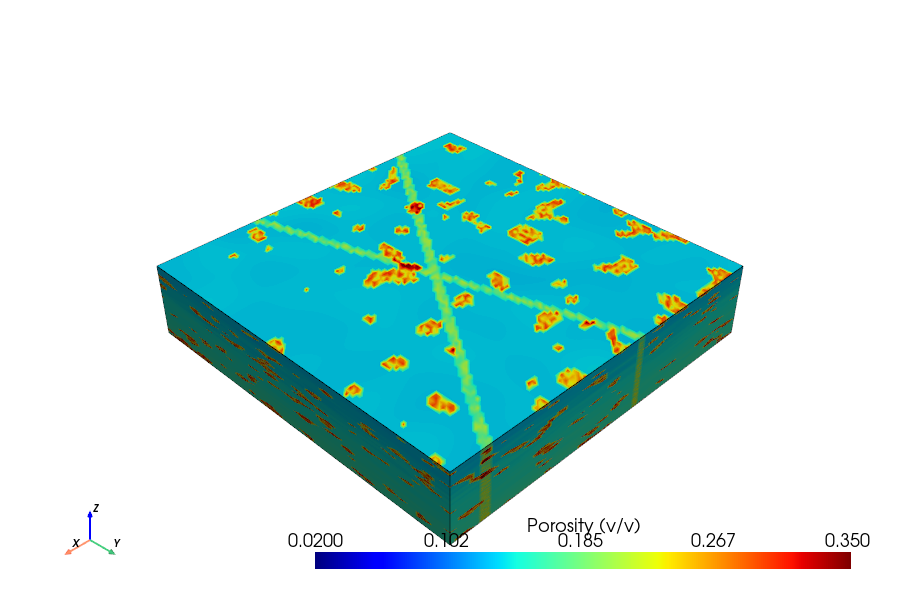

In [3]:
import numpy as np
import pyvista as pv
from scipy.ndimage import gaussian_filter

# 1. Grid Dimensions
nx, ny, nz = 100, 100, 100
dx, dy, dz = 10.0, 10.0, 2.0

x = np.linspace(0, nx * dx, nx)
y = np.linspace(0, ny * dy, ny)
z = np.linspace(0, nz * dz, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# 2. Simulate Porosity
np.random.seed(42)
matrix_poro = gaussian_filter(np.random.normal(0.14, 0.04, (nx, ny, nz)), sigma=(5.0, 5.0, 1.5))
matrix_poro = np.clip(matrix_poro - 0.03 * (Z / Z.max()) + 0.02, 0.01, 0.30)

# Vugs & Fractures
vug_blobs = gaussian_filter(np.random.uniform(0, 1, (nx, ny, nz)), sigma=1.8)
vug_mask = vug_blobs > np.quantile(vug_blobs, 0.95)
vug_poro = np.zeros_like(matrix_poro)
vug_poro[vug_mask] = np.random.uniform(0.08, 0.18, np.sum(vug_mask))

frac_mask = (np.abs(X - 0.7 * Y - 200) < 15) | (np.abs(X + 0.3 * Y - 700) < 12)
frac_poro = np.zeros_like(matrix_poro)
frac_poro[frac_mask] = np.random.uniform(0.03, 0.08, np.sum(frac_mask))

total_porosity = np.clip(matrix_poro + vug_poro + frac_poro, 0.01, 0.40)

# 3. PyVista Setup
grid = pv.RectilinearGrid(x, y, z)
grid.point_data["Total_Porosity"] = total_porosity.flatten(order="F")

# 4. Render 3D Volumetric Grid
pv.set_jupyter_backend('static')  # Generates an inline, crisp 3D plot

plotter = pv.Plotter(window_size=[900, 600])

# Extract the outer surface of the 3D grid block
surface = grid.extract_surface()

plotter.add_mesh(
    surface, 
    scalars="Total_Porosity",
    cmap="jet", 
    clim=[0.02, 0.35],
    scalar_bar_args={"title": "Porosity (v/v)"}
)

plotter.add_bounding_box(color="black")
plotter.add_axes()
plotter.view_isometric()

plotter.show()